# Coursework: Image Matching
### Visual Computing

This notebook contains exercises related to Part Two of  Coursework 2: Rendering and Image Matching,  CM22010 Visual Computing. It consists of two tasks: image stitching and panorama stitching. 

**Grading Scheme (6 points total)**:

- Task 1 **Image Stitching**: 3 points
- Task 2 **Panorama Stitching**: 3 points




## Imports + load images

In [58]:
# Implement image stitching

# HELPFUL WEBSITE: https://kushalvyas.github.io/stitching.html
# 1. Image Registration
# 2. Calibration
# 3. Blending

import os
import numpy as np
from PIL import Image 
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, maximum_filter, distance_transform_edt
import random
import cv2

image_files = sorted([f for f in os.listdir("images") if f.endswith((".jpeg", ".jpg"))])

print(f"Found {len(image_files)} images: {image_files}")

grey_imgs = []
colour_imgs = []

for file in image_files:
    path = os.path.join("images", file)

    # greyscale for feature detection
    img_grey = Image.open(path).convert("L")
    img_grey = img_grey.rotate(270, expand=True)
    # img_grey = img_grey.resize((img_grey.width // 4, img_grey.height // 4))
    grey_imgs.append(np.array(img_grey, dtype=np.float32))

    # Colour for output
    img_colour = Image.open(path).convert("RGB")
    img_colour = img_colour.rotate(270, expand=True)
    # img_colour = img_colour.resize((img_grey.width, img_grey.height))
    colour_imgs.append(np.array(img_colour, dtype=np.float32))

print(f"Greyscale shapes: {[img.shape for img in grey_imgs]}")
print(f"Colour shapes: {[img.shape for img in colour_imgs]}")


Found 4 images: ['IMG_1.jpeg', 'IMG_2.jpeg', 'IMG_3.jpeg', 'IMG_4.jpeg']
Greyscale shapes: [(4032, 3024), (4032, 3024), (4032, 3024), (4032, 3024)]
Colour shapes: [(4032, 3024, 3), (4032, 3024, 3), (4032, 3024, 3), (4032, 3024, 3)]


## Find Keypoints

In [59]:
# Sobel edge detection filters
sobel_x = np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
])

sobel_y = np.array([
[-1,-2,-1],
[0,0,0],
[1,2,1]
])

def findHarrisCorners(image, top_k=1000):
    # compute gradients
    imgx = convolve(image, sobel_x)
    imgy = convolve(image, sobel_y)

    # compute Harris matrix components
    imgxx = imgx ** 2
    imgyy = imgy ** 2
    imgxy = imgx * imgy

    # sum values in a window
    window = np.ones((3, 3))
    Sxx = convolve(imgxx, window)
    Syy = convolve(imgyy, window)
    Sxy = convolve(imgxy, window)

    # compute harris corner response
    k = 0.04
    det = (Sxx * Syy) - (Sxy ** 2)
    trace = Sxx + Syy
    R = det - k * (trace ** 2)

    local_max = maximum_filter(R, size=3)
    R[R < local_max] = 0

    # Adaptive thresholding
    floor_threshold = 1e-6
    coords = np.argwhere(R > floor_threshold)
    values = R[R > floor_threshold]

    if len(values) > top_k:
        idx = np.argsort(values)[-top_k:]
        points = coords[idx]
    else:
        points = coords

    return np.array(points)

points = []
for i, img in enumerate(grey_imgs):
    corners = findHarrisCorners(img)
    points.append(corners)
    print(f"Image {i}: {len(corners)} corners")

Image 0: 1000 corners
Image 1: 1000 corners
Image 2: 1000 corners
Image 3: 1000 corners


## Match Features

In [60]:
def getAllPatches(img, points, size=9):
    h, w = img.shape
    offset = size // 2
    patches = []
    valid_points = []

    for y, x in points:
        if y - offset >= 0 and y + offset < h and x - offset >= 0 and x + offset < w:
            patch = img[y-offset : y+offset+1, x-offset : x+offset+1].flatten()

            patch_std = np.std(patch)

            if patch_std > 1e-5:
                patch = (patch - np.mean(patch)) / patch_std

            patches.append(patch)
            valid_points.append([y, x])
    
    return np.array(patches), np.array(valid_points)

def matchFeatures(img1, img2, points1, points2, patch_size=9):
    desc1, v_pts1 = getAllPatches(img1, points1, patch_size)
    desc2, v_pts2 = getAllPatches(img2, points2, patch_size)

    if len(desc1) == 0 or len(desc2) == 0:
        return []

    dist_matrix = np.sum(desc1**2, axis=1)[:, np.newaxis] + np.sum(desc2**2, axis=1) - 2 * np.dot(desc1, desc2.T)
    
    sorted_indices = np.argsort(dist_matrix, axis=1)

    matches = []
    for i in range(len(desc1)):
        best_idx = sorted_indices[i, 0]
        second_best_idx = sorted_indices[i, 1]

        ratio = dist_matrix[i, best_idx] / (dist_matrix[i, second_best_idx] + 1e-10)

        if ratio < 0.7:
            matches.append((v_pts1[i], v_pts2[best_idx]))

    return matches


## Compute Homographies

In [61]:
def computeHomography(matches):
    A = []

    for (p1, p2) in matches:
        y1, x1 = p1
        y2, x2 = p2

        A.append([
            -x1, -y1, -1, # coefficients for h11, h12, h13
            0, 0, 0,  # no contribution to second row of H
            x1*x2, y1*x2, x2 # coefficients involving h31, h32, h33
        ])

        A.append([
            0, 0, 0, # no contribution to first row of H
            -x1, -y1, -1, # coefficients of h21, h22, h23
            x1*y2, y1*y2, y2 # coefficients involving h31, h32, h33
        ])

    A = np.array(A)

    U, s, vt = np.linalg.svd(A)

    h = vt[-1]
    H = h.reshape(3, 3)
    
    return H / H[-1, -1] # normalise

def RANSAC(matches, threshold=5, iterations=1000):
    if len(matches) < 4:
        return None, []
    
    best_inliers = []
    bestH = None

    for i in range(iterations):
        sample = random.sample(matches, min(4, len(matches)))

        if len(sample) < 4:
            continue

        H = computeHomography(sample)

        if np.linalg.matrix_rank(H) < 3:
            continue

        current_inliers = []

        for (p1, p2) in matches:
            x1, y1 = p1[1], p1[0]
            x2, y2 = p2[1], p2[0]

            p1_h = np.array([x1, y1, 1])

            p2_proj = H @ p1_h
            p2_proj /= p2_proj[2]

            error = np.linalg.norm(p2_proj[:2] - np.array([x2, y2]))

            if error < threshold:
                current_inliers.append((p1, p2))
        
        if len(current_inliers) > len(best_inliers):
            best_inliers = current_inliers
            bestH = H

    if len(best_inliers) > 4:
        bestH = computeHomography(best_inliers)

    return bestH, best_inliers

## Blending functions

In [62]:
def getFeatheredMask(warp_img):
    # 1. Create binary mask of the warped image
    mask = (warp_img.sum(axis=2) > 0).astype(np.float32)
    
    # 2. Compute distance from the nearest black pixel (the edge)
    dist = distance_transform_edt(mask)
    
    # 3. Normalise distance to 0-1
    if dist.max() > 0:
        dist = dist / dist.max()
    
    return dist

### 1. Task 1 Image Stitching (3 points)
Image stitching involves aligning TWO images together to create a larger composite.

Note: You have to use your custom code (without using pre-built OpenCV libraries which would give one line of code of image stitching).


**Task description:**
- Stitching of two images together by finding corresponding points, aligning the images using a transformation.
- Optional: use blending techniques (such as linear blending) to avoid visible seams where the images overlap.

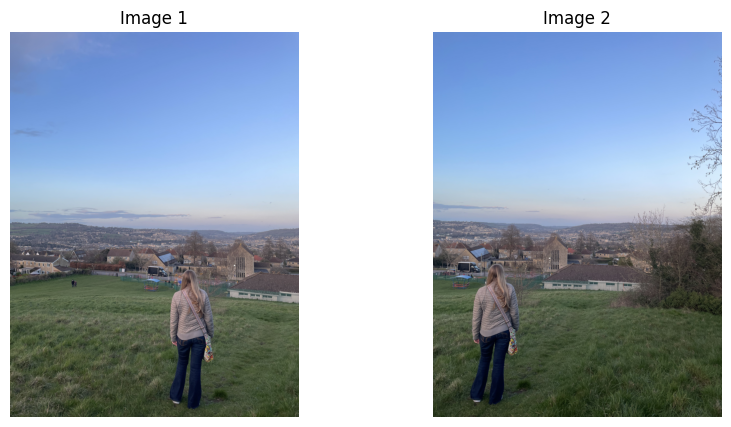

Found 179 matches
Homography computed
Inliers found: 60/179


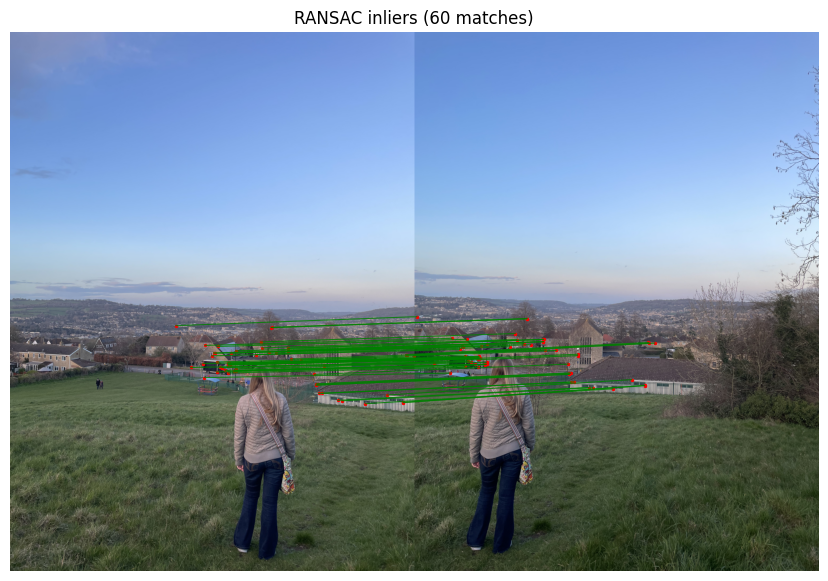

Canvas computed
Warping images
Blending set to: False


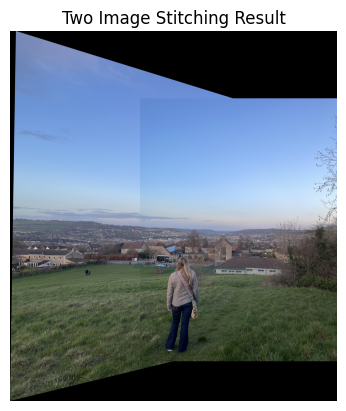

In [63]:
img1 = colour_imgs[1]
img2 = colour_imgs[2]

grey1 = grey_imgs[1]
grey2 = grey_imgs[2]

pts1 = points[1]
pts2 = points[2]


# --- Plotting 2 original images

plt.figure(figsize=(10,5), dpi=100)

plt.subplot(1,2,1)
plt.imshow(img1.astype(np.uint8))
plt.title("Image 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2.astype(np.uint8))
plt.title("Image 2")
plt.axis("off")

plt.show()


# --- Match features ---
matches = matchFeatures(grey1, grey2, pts1, pts2)
print(f"Found {len(matches)} matches")

if len(matches) < 4:
    raise ValueError("Not enough matches to compute homography")


# --- Compute homography ---
H, inlier_matches = RANSAC(matches, threshold=5, iterations=2000)

if H is None:
    raise ValueError("RANSAC failed")

print("Homography computed")
print(f"Inliers found: {len(inlier_matches)}/{len(matches)}")

# --- Plot inlier matches after RANSAC ---

h1, w1 = grey1.shape
h2, w2 = grey2.shape

height = max(h1, h2)
width = w1 + w2

combined = np.zeros((height, width, 3), dtype=np.uint8)

combined[:h1, :w1] = img1
combined[:h2, w1:w1+w2] = img2

plt.figure(figsize=(15, 7), dpi=100)
plt.imshow(combined)
plt.title(f"RANSAC inliers ({len(inlier_matches)} matches)")

for (p1, p2) in inlier_matches:
    y1, x1 = p1
    y2, x2 = p2

    x2_shifted = x2 + w1

    plt.plot([x1, x2_shifted], [y1, y2], color="green", linewidth=0.8, alpha=0.8)
    plt.scatter([x1, x2_shifted], [y1, y2], s=2, color="red")

plt.axis("off")
plt.show()


# --- Compute canvas ---
h1, w1 = grey1.shape
h2, w2 = grey2.shape

corners1 = np.array([[0,0,1],[w1,0,1],[0,h1,1],[w1,h1,1]]).T
corners2 = np.array([[0,0,1],[w2,0,1],[0,h2,1],[w2,h2,1]]).T

# Warp img1 corners into img2 space
warped_corners1 = H @ corners1
warped_corners1 /= warped_corners1[2,:]
warped_corners2 = corners2.copy()

all_corners = np.hstack((warped_corners1[:2,:], warped_corners2[:2,:]))

min_x, min_y = np.floor(all_corners.min(axis=1)).astype(int)
max_x, max_y = np.ceil(all_corners.max(axis=1)).astype(int)

out_w = max_x - min_x
out_h = max_y - min_y

# Translation
T = np.array([
    [1, 0, -min_x],
    [0, 1, -min_y],
    [0, 0, 1]
], dtype=np.float32)

print("Canvas computed")


print("Warping images")

warp1 = cv2.warpPerspective(
    img1,
    T @ H,
    (out_w, out_h),
    flags=cv2.INTER_LINEAR, # Uses bilinear interpolation for smoother pixel values
    borderMode=cv2.BORDER_CONSTANT # Fills areas outside the image with a constant value (black)
)

warp2 = cv2.warpPerspective(
    img2,
    T,
    (out_w, out_h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT
)

blending = False
print(f"Blending set to: {blending}")

if not blending:
    # Create empty canvas
    panorama = np.zeros((out_h, out_w, 3), dtype=np.uint8)

    # Masks for valid pixels
    mask1 = (warp1.sum(axis=2) > 0)
    mask2 = (warp2.sum(axis=2) > 0)

    # Place first image
    panorama[mask1] = warp1[mask1]

    # Place second image
    panorama[mask2] = warp2[mask2]

    plt.imshow(panorama)
    plt.title("Two Image Stitching Result")
    plt.axis("off")
    plt.show()
else:
    # Create distance-based masks (1 = image, 0 = black)
    m1_dist = getFeatheredMask(warp1)
    m2_dist = getFeatheredMask(warp2)

    # Expand to 3 channels
    m1 = np.stack([m1_dist]*3, axis=-1)
    m2 = np.stack([m2_dist]*3, axis=-1)

    # Blend using distance weights
    denom = m1 + m2
    panorama = np.divide((warp1 * m1) + (warp2 * m2), denom, out=np.zeros_like(warp1), where=denom > 1e-5)    
    
    panorama = np.clip(panorama, 0, 255).astype(np.uint8)

    plt.imshow(panorama)
    plt.title(f"Two Image Stitching Result with Distance-Based Feathering")
    plt.axis("off")
    plt.show()

### 2. Task 2 Panorama Stitching (3 points)
Panorama stitching involves aligning multiple images (minimally 3 images) to create a single wide-angle composite.

Note: You have to use your custom code (without using pre-built OpenCV libraries which would give one line of code of panorama stitching).

**Task description:**
- Implement panorama stitching with multiple images, at least three images.
- Use projective transformations to align images.
- Optional: You can explore techniques like feathering, linear blending for better panaromas.



--- Computing Pairwise Homographies ---
Matching image 0 to image 1...
  Found 240 matches
  Homography computed successfully
Matching image 1 to image 2...
  Found 179 matches
  Homography computed successfully
Matching image 2 to image 3...
  Found 184 matches
  Homography computed successfully

--- Chaining Homographies ---
Reference image (middle): 2
Image 1: combined H computed
Image 0: combined H computed
Image 3: combined H computed

--- Computing Canvas Bounds ---
Canvas size: 10841 x 10520
Min: (-6404, -3970), Max: (4437, 6550)

--- Warping Images ---
Processing image 0...
Processing image 1...
Processing image 2...
Processing image 3...

--- Plotting Result ---


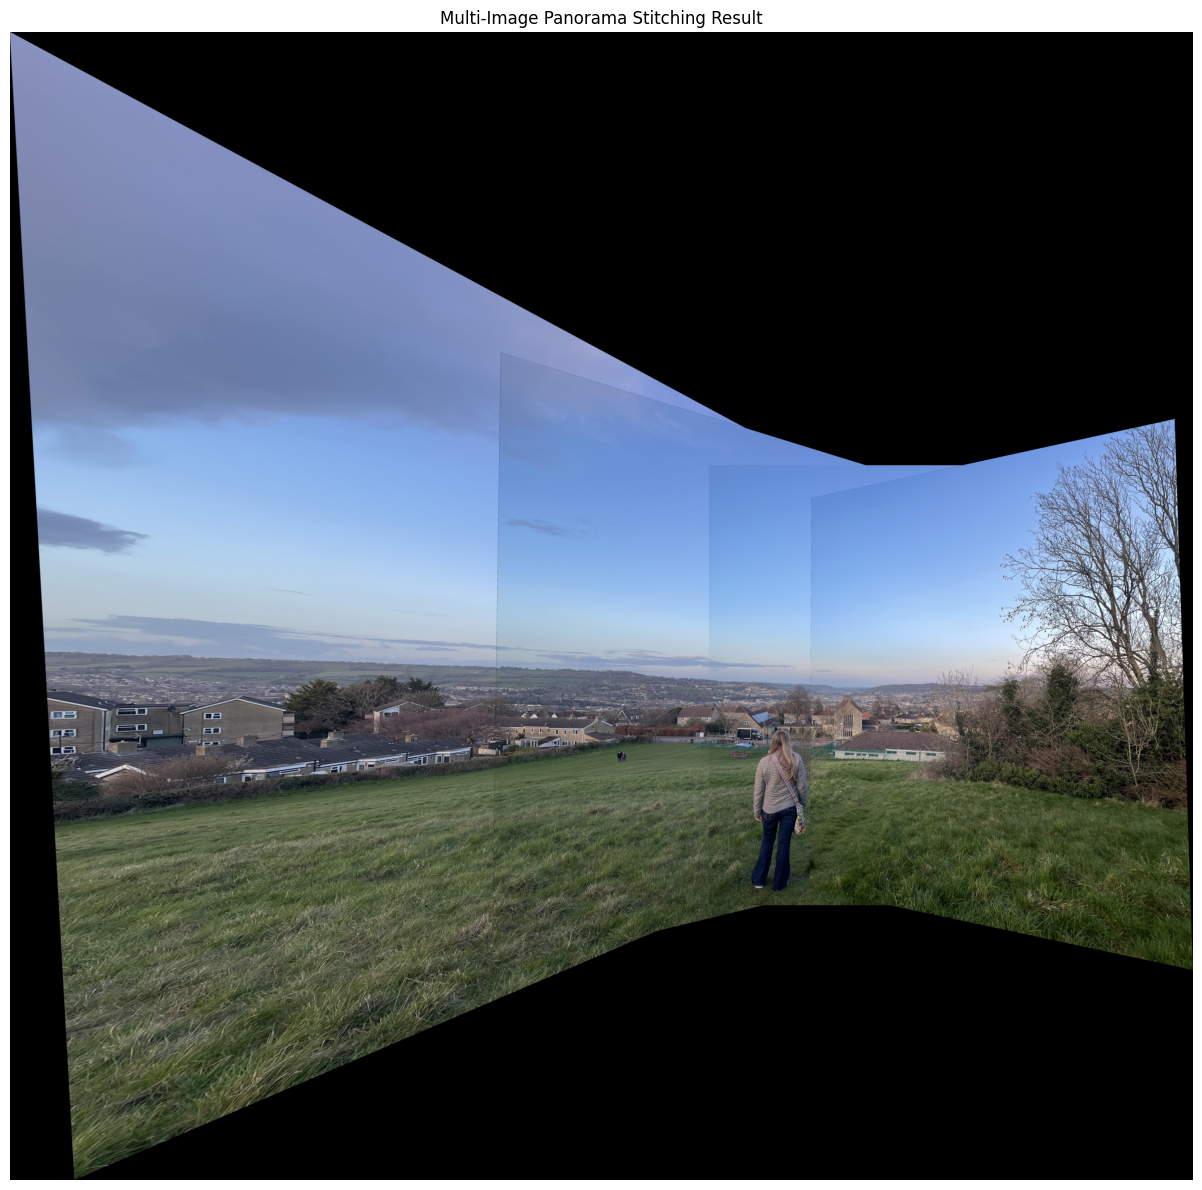

In [64]:
print("\n--- Computing Pairwise Homographies ---")

pairwise_H = []

for i in range(len(grey_imgs) - 1):
    print(f"Matching image {i} to image {i+1}...")
    matches = matchFeatures(grey_imgs[i], grey_imgs[i+1], points[i], points[i+1])
    print(f"  Found {len(matches)} matches")
    
    if len(matches) < 4:
        print(f"  ERROR: Not enough matches! Using identity.")
        pairwise_H.append(np.eye(3))
        continue
    
    H, _ = RANSAC(matches, threshold=5, iterations=2000)
    
    if H is None:
        print(f"  ERROR: RANSAC failed! Using identity.")
        pairwise_H.append(np.eye(3))
    else:
        pairwise_H.append(H)
        print(f"  Homography computed successfully")


print("\n--- Chaining Homographies ---")

combined_H = [np.eye(3) for _ in range(len(grey_imgs))]
mid = len(grey_imgs) // 2

# Middle image is reference (identity)
combined_H[mid] = np.eye(3)
print(f"Reference image (middle): {mid}")

# Chain BACKWARDS: each image is transformed relative to its right neighbor
for i in range(mid - 1, -1, -1):
    # H[i] transforms image i to the coordinate system of image i+1
    # To get world coordinates, apply H[i+1]'s transformation
    combined_H[i] = combined_H[i+1] @ pairwise_H[i]
    print(f"Image {i}: combined H computed")

# Chain FORWARDS: each image is transformed relative to its left neighbor
for i in range(mid + 1, len(grey_imgs)):
    # H[i] = H[i-1] @ inv(H[i-1 -> i])
    combined_H[i] = combined_H[i-1] @ np.linalg.inv(pairwise_H[i-1])
    print(f"Image {i}: combined H computed")


print("\n--- Computing Canvas Bounds ---")

per_image_corners = []

for i, img in enumerate(grey_imgs):
    h, w = img.shape
    # Four corners of the image
    c = np.array([[0, 0, 1], [w, 0, 1], [0, h, 1], [w, h, 1]]).T
    # Transform to world coordinates
    p = combined_H[i] @ c
    p /= p[2, :]
    per_image_corners.append(p[:2, :])

all_corners = np.hstack(per_image_corners)
min_x, min_y = np.floor(all_corners.min(axis=1)).astype(int)
max_x, max_y = np.ceil(all_corners.max(axis=1)).astype(int)

out_w = max_x - min_x
out_h = max_y - min_y

print(f"Canvas size: {out_w} x {out_h}")
print(f"Min: ({min_x}, {min_y}), Max: ({max_x}, {max_y})")
 
# Translation matrix to shift everything into positive coordinates
T = np.array([
    [1, 0, -min_x],
    [0, 1, -min_y],
    [0, 0, 1]
], dtype=np.float32)


print("\n--- Warping Images ---")
 
panorama = np.zeros((out_h, out_w, 3), dtype=np.float32)
 
for i in range(len(grey_imgs)):
    print(f"Processing image {i}...")
    
    # Warp the image
    final_H = T @ combined_H[i]
    
    warped = cv2.warpPerspective(
        colour_imgs[i].astype(np.uint8),
        final_H,
        (out_w, out_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT
    )
    
    # Create mask for valid pixels
    mask = (warped.sum(axis=2) > 0)

    panorama[mask] = warped[mask]

panorama = np.clip(panorama, 0, 255).astype(np.uint8)


print("\n--- Plotting Result ---")

plt.figure(figsize=(20, 12), dpi=100)
plt.imshow(panorama)
plt.axis("off")
plt.title("Multi-Image Panorama Stitching Result")
plt.tight_layout()
plt.show()
 
# # Save the result
# output_path = "panorama_output.jpg"
# Image.fromarray(panorama).save(output_path)
# print(f"\nPanorama saved to {output_path}")